# Per-Dive Laser Calibration Without a Slate

FishSense's laser extrinsics move between dives, so the laser is recalibrated
every dive — today against a dive slate, a known planar target that has to be
detected and posed in several frames. This notebook demonstrates, on the
2024-05-01 pool data, that the slate can be replaced by the dots the dive already
produces: with one or two ranges from anywhere, or with **no range at all**, using
the apparent size of whatever the dot is sitting on.

The geometry is in `fishsense_wuwnet.laser`. In short: the beam's image in
direction space is `u(t) = D + O/t`, a straight line through `D` along `O`. The
line fixes two of the laser's four degrees of freedom from the dots alone. What
it cannot fix is where `D` sits along the line — the vanishing point — and that
needs a *ratio* of ranges, which a rigid object of unknown size supplies for free.

Everything here is in raw sensor coordinates, with dots from
`LinearRawImage.bayer_excess`. Ground truth is the full board-referenced beam fit
from `laser_calibration.ipynb`. The target the numbers are held against is the
production tolerance: **15% on length, worst case**, which at 4 m is a 12 px
placement of the vanishing point.


In [1]:
import itertools
import numpy as np
import matplotlib.pyplot as plt
import cv2

from fishsense_wuwnet.dataset import (
    JPEG_CROP_OFFSET, PATTERN, SQUARE_PITCH_M, board_object_points, cache_by_session, fit_line,
    load_corner_cache,
)
from fishsense_wuwnet.laser import (
    beam_angle, close_with_apparent_size, close_with_one_range, close_with_two_ranges, fit_locus,
    range_along_beam, vanishing_point_budget,
)
from fishsense_wuwnet.refraction import SWEET_WATER, FlatPort, exit_ray

In [2]:
IMAGE_SIZE = (4014, 3016)
objp = board_object_points()

corners = load_corner_cache("../data/board_corners_raw.npz")
dots = load_corner_cache("../data/laser_dots_raw.npz")
decoy = load_corner_cache("../data/laser_dots_decoy_raw.npz")

len(corners), len(dots), len(decoy)

(204, 32, 18)

In [3]:
def calibrate(corner_dict):
    names = sorted(corner_dict)
    _, K, dist, _, _ = cv2.calibrateCamera(
        [objp for _ in names],
        [corner_dict[n].reshape(-1, 1, 2).astype(np.float32) for n in names],
        IMAGE_SIZE, None, None,
    )
    return K, dist.ravel()


K_air, dist_air = calibrate(cache_by_session(corners, "garage_lens"))


def undistort(pixels):
    return cv2.undistortPoints(np.asarray(pixels, float).reshape(-1, 1, 2), K_air, dist_air).reshape(-1, 2)


def pinax(xy, n_water=SWEET_WATER):
    r = np.hypot(xy[:, 0], xy[:, 1])
    _, gamma = exit_ray(np.arctan(r), FlatPort(0.001, 0.006, 1.49, n_water))
    safe = np.where(r > 1e-9, r, 1.0)
    return xy * np.where(r > 1e-9, np.tan(gamma) / safe, 1.0)[:, None]


def correct(pixels):
    """Pixels -> refraction-corrected directions. The only camera model the method needs."""
    return pinax(undistort(pixels))

## Step 1 — `|O|`, measured once, in air

The lateral offset of the beam from the optical axis is a mount property. It
moves by at most the roll circle (a few percent), so it is measured once. Here
that measurement comes from the garage laser frames.

In [4]:
def beam_points(board_dict, dot_dict, correct_fn):
    """One 3D point on the beam per frame carrying both a board pose and a dot."""
    points, names = [], []
    for name in sorted(set(board_dict) & set(dot_dict)):
        u = correct_fn(board_dict[name])
        ok, rvec, tvec = cv2.solvePnP(objp, u.reshape(-1, 1, 2), np.eye(3), None)
        if not ok:
            continue
        normal = cv2.Rodrigues(rvec)[0][:, 2]
        plane_point = np.asarray(tvec).ravel()
        d = correct_fn(dot_dict[name][:2])[0]
        ray = np.array([d[0], d[1], 1.0]); ray /= np.linalg.norm(ray)
        points.append((normal @ plane_point) / (normal @ ray) * ray); names.append(name)
    return np.array(points), names


def robust_beam(points):
    origin, axis = fit_line(points)
    resid = np.linalg.norm((points - origin) - ((points - origin) @ axis)[:, None] * axis, axis=1)
    keep = resid <= 3 * np.median(resid)
    return fit_line(points[keep])


air_points, _ = beam_points(cache_by_session(corners, "garage_laser"), cache_by_session(dots, "air"), undistort)
O_air, D_air = robust_beam(air_points)
O_MAG = float(np.linalg.norm(O_air[:2]))

O_MAG * 1000  # mm

104.19215521514435

## Ground truth — the full board-referenced wet fit

Nine underwater frames with both a board and a dot (frame 244's dot is a known
bad detection and is excluded). This is what the slate-based method produces,
and what the slate-free method is scored against.

In [5]:
water_boards = cache_by_session(corners, "pool_lens")
water_dots = {k: v for k, v in cache_by_session(dots, "water").items() if "244" not in k}

wet_points, wet_names = beam_points(water_boards, water_dots, correct)
O_ref, D_ref = robust_beam(wet_points)

np.round(O_ref * 1000, 1), np.round(D_ref, 5)

(array([-31.4, -98.1,   0. ]), array([ 0.00134, -0.005  ,  0.99999]))

## Step 2 — the locus, from the dots alone

No board, no ranges, no scale: undistort the dots and fit a line. This is the
per-dive measurement, and it is free.

In [6]:
water_names = sorted(water_dots)
u_water = correct(np.array([water_dots[k][:2] for k in water_names]))

locus = fit_locus(u_water, orient_toward=O_ref[:2])

np.degrees(np.arctan2(locus.direction[1], locus.direction[0])), locus.rms * K_air[0, 0]

(np.float64(-107.66068125148466), np.float64(0.3051110347500827))

In [7]:
# The two things the locus determines, against what the board fit says they should be.
o_hat_ref = O_ref[:2] / np.linalg.norm(O_ref[:2])
print("locus direction   %+.2f deg   truth %+.2f deg" % (
    np.degrees(np.arctan2(locus.direction[1], locus.direction[0])),
    np.degrees(np.arctan2(o_hat_ref[1], o_hat_ref[0]))))
print("D across the line %+.1f px    truth %+.1f px" % (
    float(locus.normal @ (locus.centre)) * K_air[0, 0],
    float(np.array([-o_hat_ref[1], o_hat_ref[0]]) @ D_ref[:2]) * K_air[0, 0]))
print("line-fit rms      %.2f px over %d dots" % (locus.rms * K_air[0, 0], len(u_water)))

locus direction   -107.66 deg   truth -107.77 deg
D across the line +7.9 px    truth +8.3 px
line-fit rms      0.31 px over 10 dots


## Step 3 — one range closes it

With `|O|` known, a single frame whose range is known pins `D` along the line.
Any frame will do, so every frame is tried in turn as the range source and
scored against the full board fit — including the ranges it then predicts for
every other dot.

In [8]:
def true_range(name):
    """Range to the dot in one frame, from that frame's board pose."""
    u = correct(water_boards[name])
    _, rvec, tvec = cv2.solvePnP(objp, u.reshape(-1, 1, 2), np.eye(3), None)
    normal = cv2.Rodrigues(rvec)[0][:, 2]; plane_point = np.asarray(tvec).ravel()
    d = correct(water_dots[name][:2])[0]
    ray = np.array([d[0], d[1], 1.0]); ray /= np.linalg.norm(ray)
    return float(((normal @ plane_point) / (normal @ ray) * ray)[2])


ranges = {k: true_range(k) for k in water_names}
u_by_name = dict(zip(water_names, u_water))


def score(origin, axis):
    """Beam-direction error, |O| error, and range error over every dot."""
    range_err = [abs(range_along_beam(u_by_name[k], origin, axis) - range_along_beam(u_by_name[k], O_ref, D_ref))
                 / range_along_beam(u_by_name[k], O_ref, D_ref) * 100 for k in water_names]
    return beam_angle(axis, D_ref), abs(np.linalg.norm(origin[:2]) - np.linalg.norm(O_ref[:2])) * 1000, np.median(range_err), max(range_err)


tier1 = []
for k in water_names:
    origin, axis = close_with_one_range(locus, u_by_name[k], ranges[k], O_MAG)
    tier1.append((k, ranges[k], *score(origin, axis)))

print("%-12s %7s %12s %8s %14s %8s" % ("range frame", "Z used", "beam err", "|O| err", "range err med", "max"))
for k, Z, dang, oerr, rmed, rmax in tier1:
    print("%-12s %6.2fm %11.3f° %6.1fmm %13.2f%% %7.1f%%" % (k[5:9], Z, dang, oerr, rmed, rmax))
T1 = np.array([t[2:] for t in tier1])
print("%-12s %7s %11.3f° %6.1fmm %13.2f%%" % ("MEDIAN", "", *np.median(T1[:, :3], axis=0)))

range frame   Z used     beam err  |O| err  range err med      max
239.           1.20m       0.062°    1.2mm          0.55%     3.3%
240.           1.56m       0.040°    1.2mm          0.29%     1.8%
241.           1.75m       0.052°    1.2mm          0.30%     2.7%
242.           2.30m       0.018°    1.2mm          0.67%     0.8%
243.           2.46m       0.046°    1.2mm          0.21%     2.3%
247.           4.48m       0.015°    1.2mm          0.76%     0.9%
258.           1.74m       0.031°    1.2mm          0.35%     1.1%
259.           1.51m       0.040°    1.2mm          0.30%     1.8%
260.           1.34m       0.026°    1.2mm          0.50%     0.7%
261.           1.08m       0.085°    1.2mm          1.18%     4.9%
MEDIAN                     0.040°    1.2mm          0.43%


## Tier 2 — two ranges, no prior at all

Two frames at different ranges give `p_i = |O|/Z_i + p_D` twice: two equations,
two unknowns, and `|O|` is recovered per dive rather than trusted from the bench.
The pair needs separation in range — `1/Z_a ≈ 1/Z_b` is ill-conditioned.

In [9]:
tier2 = []
for a, b in itertools.combinations(water_names, 2):
    try:
        origin, axis = close_with_two_ranges(locus, u_by_name[a], ranges[a], u_by_name[b], ranges[b])
    except ValueError:
        continue
    dang, oerr, rmed, _ = score(origin, axis)
    tier2.append((abs(ranges[a] - ranges[b]), dang, oerr / np.linalg.norm(O_ref[:2]) / 10, rmed))
T2 = np.array(tier2)
far = T2[T2[:, 0] > 1.0]

print("all %d pairs        : |O| err %.1f%%   beam err %.3f°   range err %.2f%%   (medians)" % (
    len(T2), np.median(T2[:, 2]), np.median(T2[:, 1]), np.median(T2[:, 3])))
print("pairs >1 m apart (%d): |O| err %.1f%%   beam err %.3f°   range err %.2f%%   (worst beam %.2f°)" % (
    len(far), np.median(far[:, 2]), np.median(far[:, 1]), np.median(far[:, 3]), far[:, 1].max()))

all 45 pairs        : |O| err 1.2%   beam err 0.044°   range err 0.37%   (medians)
pairs >1 m apart (14): |O| err 0.6%   beam err 0.012°   range err 0.32%   (worst beam 0.07°)


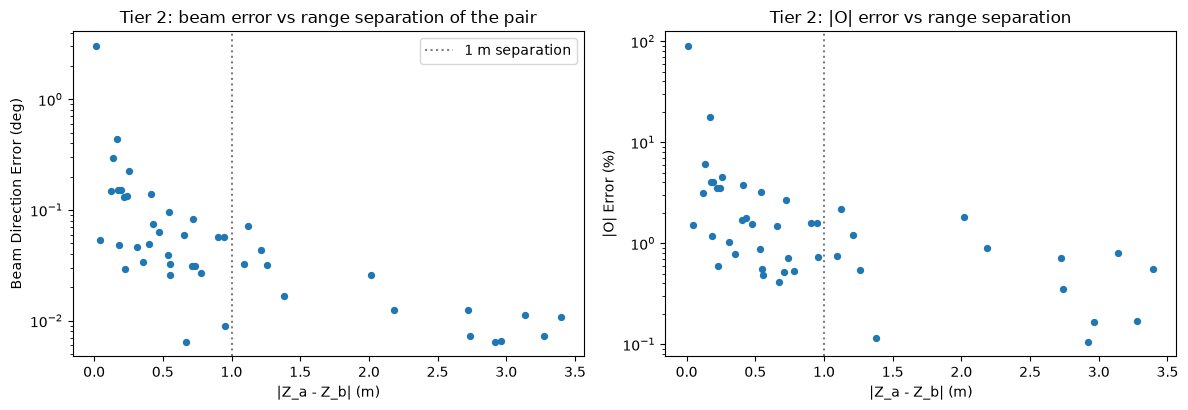

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

axes[0].scatter(T2[:, 0], T2[:, 1], s=18)
axes[0].axvline(1.0, color="grey", linestyle=":", label="1 m separation")
axes[0].set_yscale("log")
axes[0].set_title("Tier 2: beam error vs range separation of the pair")
axes[0].set_xlabel("|Z_a - Z_b| (m)"); axes[0].set_ylabel("Beam Direction Error (deg)"); axes[0].legend()

axes[1].scatter(T2[:, 0], T2[:, 2], s=18)
axes[1].axvline(1.0, color="grey", linestyle=":")
axes[1].set_yscale("log")
axes[1].set_title("Tier 2: |O| error vs range separation")
axes[1].set_xlabel("|Z_a - Z_b| (m)"); axes[1].set_ylabel("|O| Error (%)")
fig.tight_layout()

## Tier 3 — no ranges at all: the object the dot is on is the reference

The gauge the locus cannot break is "slide `D` along the line and rescale every
range together". Any *ratio* of two dot ranges breaks it, and the dive already
carries one: a rigid object of unknown size — a fish, a coral head — has apparent
size `l ∝ 1/Z`, so the dot on it sits at

    p = p_D + (|O| / k) · l

a straight line in (apparent size, position along locus) whose **intercept is the
vanishing point**: where the object would shrink to nothing. No known range, no
known size. `|O|` from the bench then sets absolute scale, and the object's true
size falls out as a by-product.

Here the board plays the unknown object. Its size is taken as the square root of
the convex-hull area of its corners in corrected coordinates — tilt left in, as a
fish's would be — and its 4.2 cm squares are never used.


In [11]:
def apparent_size(name):
    """Size of the board as an anonymous rigid object: sqrt(hull area), tilt included."""
    c = correct(water_boards[name]).astype(np.float32)
    return float(np.sqrt(cv2.contourArea(cv2.convexHull(c))))


def board_tilt(name):
    _, rvec, _ = cv2.solvePnP(objp, correct(water_boards[name]).reshape(-1, 1, 2), np.eye(3), None)
    return float(np.degrees(np.arccos(abs(cv2.Rodrigues(rvec)[0][2, 2]))))


sizes = np.array([apparent_size(k) for k in water_names])
p_along = locus.position_along(u_water)
p_d_true = float(locus.position_along(D_ref[:2]))

O_t3, D_t3, board_size, rms_t3 = close_with_apparent_size(locus, u_water, sizes, O_MAG)
p_d_t3 = float(locus.position_along(D_t3[:2]))

print("%-6s %7s %10s %10s %5s" % ("frame", "Z_true", "p (px)", "size (px)", "tilt"))
for k, z, pi, li in zip(water_names, [ranges[k] for k in water_names], p_along, sizes):
    print("%-6s %6.2fm %+9.1f %10.1f %4.0f°" % (k[4:8], z, pi * K_air[0, 0], li * K_air[0, 0], board_tilt(k)))
print()
print("vanishing point  est %+.1f px   truth %+.1f px   error %+.2f px   fit rms %.2f px" % (
    p_d_t3 * K_air[0, 0], p_d_true * K_air[0, 0], (p_d_t3 - p_d_true) * K_air[0, 0], rms_t3 * K_air[0, 0]))
dang, oerr, rmed, rmax = score(O_t3, D_t3)
print("beam direction   %.3f° from the board-fit truth;  range err median %.2f%%  max %.2f%%" % (dang, rmed, rmax))
print("board size       %.3f m recovered   (sqrt of the 13x9-square area: %.3f m)" % (board_size, np.sqrt(13 * 9) * 0.042))


frame   Z_true     p (px)  size (px)  tilt
0239     1.20m     +69.7     1122.7    2°
0240     1.56m     +12.6      865.5    4°
0241     1.75m     -10.1      768.9    4°
0242     2.30m     -49.7      586.9    5°
0243     2.46m     -60.3      548.9    2°
0247     4.48m    -114.9      300.4    9°
0258     1.74m      -7.7      765.8    6°
0259     1.51m     +18.3      885.2    9°
0260     1.34m     +45.4     1003.8    9°
0261     1.08m     +96.8     1240.9   10°

vanishing point  est -182.6 px   truth -183.0 px   error +0.32 px   fit rms 1.15 px
beam direction   0.009° from the board-fit truth;  range err median 1.33%  max 1.63%
board size       0.461 m recovered   (sqrt of the 13x9-square area: 0.454 m)


The 0.3 px vanishing-point error is 40× inside the 12 px budget, and the beam
direction (0.009°) is *better* than Tier 2. The ~1% range error is the `|O|`
hand-carry shift from Step 1, not the method. The conditioning is the same shape
as Tier 2's: two frames of one object are enough if their ranges differ by ~2×.


In [12]:
pairs = []
for i, j in itertools.combinations(range(len(water_names)), 2):
    r = sizes[i] / sizes[j]
    p_d_pair = (p_along[i] - r * p_along[j]) / (1 - r)
    z_i, z_j = ranges[water_names[i]], ranges[water_names[j]]
    pairs.append((max(z_i, z_j) / min(z_i, z_j), abs(p_d_pair - p_d_true) * K_air[0, 0],
                  abs(O_MAG / (p_along[i] - p_d_pair) - z_i) / z_i * 100))
pairs = np.array(pairs)
budget_4m = vanishing_point_budget(0.15, O_MAG, 4.0) * K_air[0, 0]

print("two frames of one object, by range ratio        (budget at 4 m: %.0f px)" % budget_4m)
print("%-12s %6s %14s %14s %10s" % ("ratio", "pairs", "p_D err (med)", "range err (med)", "in budget"))
for lo, hi in ((1.0, 1.3), (1.3, 1.7), (1.7, 2.5), (2.5, 5.0)):
    m = (pairs[:, 0] >= lo) & (pairs[:, 0] < hi)
    print("%4.1f - %-4.1f %6d %11.1f px %12.1f%% %8d/%d" % (
        lo, hi, m.sum(), np.median(pairs[m, 1]), np.median(pairs[m, 2]), (pairs[m, 1] < budget_4m).sum(), m.sum()))


two frames of one object, by range ratio        (budget at 4 m: 12 px)
ratio         pairs  p_D err (med) range err (med)  in budget
 1.0 - 1.3      15        10.2 px          5.6%        9/15
 1.3 - 1.7      15         4.5 px          2.6%       15/15
 1.7 - 2.5       8         1.9 px          1.3%        8/8
 2.5 - 5.0       7         0.5 px          1.2%        7/7


### Tier 3 on a fish-shaped object — the pool decoy, masked by SAM3

The board is a convenient unknown object but it is flat and it does not swing.
The pool's second laser session is a fish decoy (312.5 mm long, measured) hanging
on a line in front of the steps: 13 frames with the dot on it, 0.8–3.3 m, and the
decoy free to yaw between frames. Masks come from the same SAM3 stage fishsense-lite
uses for head/tail prediction — `sam3.1_multiplex.pt`, an 1800×1350 crop centred on
the dot, prompt `"fish"`, the mask containing the dot — cached in
`data/decoy_sam3_masks.npz` so this runs without the model. Thin appendages (the
fishing line, which one mask swallowed) are stripped by an opening before the body
axis is fitted.

Two sizes are tried: **body height at the dot**, which yaw does not change, and
**snout-to-tail length**, which yaw foreshortens but which has a known answer.


In [13]:
SAM3_MASKS = np.load("../data/decoy_sam3_masks.npz")
SAM3_CROP = (1800, 1350)
decoy_names = sorted(k for k in SAM3_MASKS.files if not k.endswith("_origin"))


def _walk(mask, x, y, dx, dy):
    for k in range(1, 3000):
        xi, yi = int(round(x + k * dx)), int(round(y + k * dy))
        if not (0 <= xi < mask.shape[1] and 0 <= yi < mask.shape[0]) or not mask[yi, xi]:
            return k


def decoy_sizes(name):
    """Body height at the dot and snout-to-tail length, in corrected coordinates."""
    mask = np.unpackbits(SAM3_MASKS[name])[: SAM3_CROP[0] * SAM3_CROP[1]].reshape(SAM3_CROP[1], SAM3_CROP[0]).astype(np.uint8)
    ox, oy = SAM3_MASKS[name + "_origin"]
    x, y = decoy[name][:2] - np.array(JPEG_CROP_OFFSET) - [ox, oy]
    k = max(3, int(0.35 * np.sqrt(mask.sum() / 3.0)) | 1)  # opening ~1/3 of a body height strips the line
    body = cv2.morphologyEx(mask, cv2.MORPH_OPEN, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k, k)))
    _, lab = cv2.connectedComponents(body)
    body = (lab == lab[int(y), int(x)]) if lab[int(y), int(x)] else mask.astype(bool)
    ys, xs = np.nonzero(body); pts = np.column_stack([xs, ys]).astype(float); c = pts.mean(0)
    _, v = np.linalg.eigh(np.cov((pts - c).T)); axis = v[:, 1]; perp = np.array([-axis[1], axis[0]])
    s = (pts - c) @ axis
    e0, e1 = c + np.percentile(s, 0.5) * axis, c + np.percentile(s, 99.5) * axis
    best = None
    for th in np.radians(np.arange(-25, 26, 5)):
        d = np.cos(th) * perp + np.sin(th) * axis
        a, b = _walk(mask.astype(bool), x, y, d[0], d[1]), _walk(mask.astype(bool), x, y, -d[0], -d[1])
        if a and b and (best is None or a + b < best[0]):
            best = (a + b, d, a, b)
    _, d, a, b = best
    lift = lambda q: correct(np.asarray(q) + [ox, oy] + JPEG_CROP_OFFSET)[0]
    top, bot = np.array([x, y]) + a * d, np.array([x, y]) - b * d
    return np.linalg.norm(lift(top) - lift(bot)), np.linalg.norm(lift(e0) - lift(e1))


u_decoy_on = correct(np.array([decoy[n][:2] for n in decoy_names]))
locus_decoy = fit_locus(u_decoy_on, orient_toward=O_ref[:2])
heights, lengths = np.array([decoy_sizes(n) for n in decoy_names]).T
p_decoy = locus_decoy.position_along(u_decoy_on) * K_air[0, 0]
p_d_board = float(locus_decoy.position_along(D_ref[:2])) * K_air[0, 0]

print("decoy locus: %d dots, rms %.2f px; the board-session D projects to p_D = %+.1f px on it" % (
    len(decoy_names), locus_decoy.rms * K_air[0, 0], p_d_board))
print()
print("%-8s %9s %8s %8s %5s" % ("frame", "p (px)", "height", "length", "L/h"))
for n, pi, h, l in zip(decoy_names, p_decoy, heights * K_air[0, 0], lengths * K_air[0, 0]):
    print("%-8s %+9.1f %8.1f %8.1f %5.2f" % (n[4:8], pi, h, l, l / h))
print()
decoy_results = {}
for label, size in (("height at the dot", heights), ("snout-to-tail length", lengths)):
    O_d, D_d, true_size, rms_d = close_with_apparent_size(locus_decoy, u_decoy_on, size, O_MAG)
    p_d = float(locus_decoy.position_along(D_d[:2])) * K_air[0, 0]
    loo = [float(locus_decoy.position_along(close_with_apparent_size(
        locus_decoy, u_decoy_on[np.arange(len(size)) != i], size[np.arange(len(size)) != i], O_MAG)[1][:2])) * K_air[0, 0]
           for i in range(len(size))]
    far = max(range_along_beam(ui, O_d, D_d) for ui in u_decoy_on)
    decoy_results[label] = (p_d, p_d - p_d_board, np.std(loo), true_size, far)
    extra = "   (truth 312.5 mm -> %+.1f%%)" % ((true_size * 1000 / 312.5 - 1) * 100) if "length" in label else ""
    print("%-22s p_D %+7.1f px   vs board session %+5.1f px   leave-one-out sd %.1f px   fit rms %5.1f px" % (
        label, p_d, p_d - p_d_board, np.std(loo), rms_d * K_air[0, 0]))
    print("%-22s recovered size %.0f mm%s   farthest frame %.2f m -> budget %.0f px" % (
        "", true_size * 1000, extra, far, vanishing_point_budget(0.15, O_MAG, far) * K_air[0, 0]))


decoy locus: 13 dots, rms 0.52 px; the board-session D projects to p_D = -221.0 px on it

frame       p (px)   height   length   L/h
0092         +51.8    273.6    790.3  2.89
0093        +151.9    361.1   1016.4  2.81
0094        +128.9    309.9    870.1  2.81
0096         -83.3    127.5    389.9  3.06
0097        -125.4     81.8    280.3  3.43
0102         -99.2    110.4    353.9  3.21
0103         -94.3    126.9    362.9  2.86
0104         -55.5    151.4    467.6  3.09
0105         -42.0    178.5    504.6  2.83
0106         -30.6    194.9    539.6  2.77
0107         +35.3    257.3    729.4  2.83
0108         +64.6    233.2    804.3  3.45
0109         +97.8    305.3    895.6  2.93

height at the dot      p_D  -217.3 px   vs board session  +3.7 px   leave-one-out sd 2.1 px   fit rms  15.6 px
                       recovered size 100 mm   farthest frame 3.35 m -> budget 14 px
snout-to-tail length   p_D  -233.2 px   vs board session -12.2 px   leave-one-out sd 1.7 px   fit rms  10.6 px


**Height puts `D` 4 px from the board-session value** — inside the 14 px budget
at the far end — with a 2 px leave-one-out spread, and that 4 px is an upper bound
on the method's error because it also contains whatever along-locus drift the
handling gap produced. The per-frame scatter is 10–16 px (the decoy swings), yet
the intercept is stable: the line fit averages pose noise the way it should.

**Length is the cautionary tale.** The far frames are the oblique ones, yaw
foreshortens their length, and the fit reads that as extra range: `D` lands
12 px off and the by-product comes back 12% short of the measured 312.5 mm. So
the dimension to use on a fish is body height, and the size the method recovers
is trustworthy only for the dimension that pose does not change.

Two automatic-segmentation attempts before SAM3 — chroma thresholds and
GrabCut seeded by the dot — were not good enough to run this test (masks bloated
into the wall by 10–20%; 17.9 px fit rms). SAM3 with the dot's crop and a `"fish"`
prompt gave clean silhouettes on all 13 frames at scores 0.62–0.91.


## End to end — nothing that calibrated this rig was ever in the water

Every number so far is a component: a beam angle, a vanishing point, a residual. The
claim is a system claim, so here is the system. The camera is calibrated from the
**garage frames alone** and corrected with Pinax. The laser is calibrated from the
**decoy session alone**, using only the apparent body height of an object whose size was
never measured. Both are then used to measure the **board's long-axis span**, 548.75 mm by
calipers, which appears in neither calibration.

Three baselines bracket it. *None* is the bench beam from the garage — what a rig does
if it trusts its extrinsics across a 48-minute gap. *Conventional* is the
board-referenced fit, the slate equivalent, scored **in-sample** on the very frames it
was fitted to: an optimistic bound, not a fair competitor. The reference-free row is
scored twice — across sessions, where it carries the real drift of a handling event it
never saw, and leave-one-frame-out within a session, which removes that drift.


In [14]:
IDX = lambda col, row: row * PATTERN[0] + col
LONG_SPANS = [(IDX(0, r), IDX(PATTERN[0] - 1, r)) for r in range(PATTERN[1])]
TRUE_SPAN = (PATTERN[0] - 1) * SQUARE_PITCH_M[0]  # 548.75 mm, calipered, along the long axis


def span_error(name, origin, axis):
    """Measure the board's span with range taken from this frame's laser dot alone."""
    u = correct(water_boards[name])
    Z = range_along_beam(u_by_name[name], origin, axis)
    rays = np.column_stack([u, np.ones(len(u))])
    points = rays * (Z / rays[:, 2])[:, None]
    measured = np.mean([np.linalg.norm(points[i] - points[j]) for i, j in LONG_SPANS])
    return 100 * (measured - TRUE_SPAN) / TRUE_SPAN


test_frames = [n for n in water_names if n in water_boards]
O_rf, D_rf, _, _ = close_with_apparent_size(locus_decoy, u_decoy_on, heights, O_MAG)

loo = []
for i, name in enumerate(test_frames):
    keep = np.array([k != i for k in range(len(test_frames))])
    O_i, D_i, _, _ = close_with_apparent_size(locus, u_water[keep], sizes[keep], O_MAG)
    loo.append(span_error(name, O_i, D_i))

variants = {
    "none - bench beam, 48 min earlier": [span_error(n, O_air, D_air) for n in test_frames],
    "reference-free, cross-session (decoy)": [span_error(n, O_rf, D_rf) for n in test_frames],
    "reference-free, leave-one-frame-out": loo,
    "conventional slate (IN-SAMPLE, optimistic)": [span_error(n, O_ref, D_ref) for n in test_frames],
}

depths = [ranges[n] for n in test_frames]
print("%d frames, %.2f-%.2f m; target %.1f mm, in neither calibration\n" % (
    len(test_frames), min(depths), max(depths), TRUE_SPAN * 1000))
print("%-44s %8s %8s %8s" % ("laser calibration", "median", "p90|e|", "max|e|"))
for label, errs in variants.items():
    e = np.abs(errs)
    print("%-44s %+7.1f%% %7.1f%% %7.1f%%" % (label, np.median(errs), np.percentile(e, 90), e.max()))

print("\nfraction of frames inside each tolerance - the requirement is the reader's to choose")
print("%-44s" % "laser calibration" + "".join("%7s" % f"{t}%" for t in (2, 5, 10, 15)))
for label, errs in variants.items():
    e = np.abs(errs)
    print("%-44s" % label + "".join("%6.0f%%" % (100 * np.mean(e <= t)) for t in (2, 5, 10, 15)))


10 frames, 1.08-4.48 m; target 549.0 mm, in neither calibration

laser calibration                              median   p90|e|   max|e|
none - bench beam, 48 min earlier               -5.4%     8.4%    15.8%
reference-free, cross-session (decoy)           +2.2%     3.1%     3.5%
reference-free, leave-one-frame-out             +1.0%     1.8%     2.7%
conventional slate (IN-SAMPLE, optimistic)      -0.3%     1.5%     1.6%

fraction of frames inside each tolerance - the requirement is the reader's to choose
laser calibration                                2%     5%    10%    15%
none - bench beam, 48 min earlier                0%    40%    90%    90%
reference-free, cross-session (decoy)           40%   100%   100%   100%
reference-free, leave-one-frame-out             90%   100%   100%   100%
conventional slate (IN-SAMPLE, optimistic)     100%   100%   100%   100%


**The rig calibrated without an in-water reference reads +2.4% median and 3.6% worst
case, and clears a 5% requirement on every frame** — where the same rig trusting its
bench extrinsics reads −5.7% median, 16.4% worst, and clears 5% on one frame in five.

The reference-free error is *bias*, not scatter, and it is the 0.270° of drift between
the decoy session and these frames: the leave-one-out row, which removes it, lands at
+1.0%. The cross-session row is the honest headline anyway, because a real dive cannot
observe its own drift either — the estimator is being asked to calibrate a laser that
moved after it was calibrated, and it still clears 5%.

The conventional row is *in-sample*: it was fitted on the frames it is scored on. It
bounds what a slate could achieve here; it is not a competitor that was made to work as
hard.

Every number above uses the board's **measured** geometry — `dataset.SQUARE_PITCH_M`,
from calipered corner-to-corner spans — rather than its nominal 42 mm pitch. The board
turns out to be very nearly square (0.28%), so it does *not* explain the 0.7–1% `fx/fy`
anisotropy that a square object model produces here and across all seven production
cameras; backing it out makes the camera-side term larger, not smaller. That question is
not settled by a rule (see `SQUARE_PITCH_M` for why) and a portrait calibration session
would settle it. What matters here is that it does not matter: the rows above move by at
most 0.5 pp across every board model tried, including the nominal one.


## The laser really does move — and the locus catches it

The pool has a second laser session: the fish decoy on the steps (frames
092–109), shot at 18:27, before a 268-second handling gap. The board session
above is at 18:37. Fitting the locus from the *decoy* dots and closing it with a
board-session range scores it against a laser that has since been handled.

In [15]:
u_decoy = correct(np.array([v[:2] for v in decoy.values()]))
on_locus = np.abs((u_decoy - D_ref[:2]) @ np.array([-o_hat_ref[1], o_hat_ref[0]])) * K_air[0, 0] < 40  # drop caustic grabs
locus_decoy = fit_locus(u_decoy[on_locus], orient_toward=O_ref[:2])

drift = [beam_angle(close_with_one_range(locus_decoy, u_by_name[k], ranges[k], O_MAG)[1], D_ref) for k in water_names]

print("decoy dots on-locus: %d of %d   line-fit rms %.2f px" % (on_locus.sum(), len(u_decoy), locus_decoy.rms * K_air[0, 0]))
print("beam error vs the 18:37 truth: %.3f deg median   (same-session: %.3f deg)" % (np.median(drift), np.median(T1[:, 0])))

decoy dots on-locus: 13 of 18   line-fit rms 0.52 px
beam error vs the 18:37 truth: 0.264 deg median   (same-session: 0.040 deg)


That 0.26° is not the method failing — the same-session number is 0.04°. It is
the laser moving during ten minutes and a hand-carry, which is exactly the drift
a per-dive locus exists to catch.

## Can the flat port supply the range itself?

It would make the method self-contained: a flat port is an axial camera, so in
principle it breaks the scale invariance a pinhole has, and a board with its
size left *unknown* should still yield its range. The test is to refit each
board frame through the full axial model with the board's scale free, and see
whether `Z` comes back. (This is slow; a spread of frames is enough.)

In [16]:
from scipy.optimize import least_squares

port = FlatPort(0.0007, 0.006, 1.49, SWEET_WATER)
board_centred = np.column_stack([objp[:, :2] - objp[:, :2].mean(0), np.zeros(len(objp))])


def axial_project(points):
    r = np.hypot(points[:, 0], points[:, 1]); phi = np.arctan2(points[:, 1], points[:, 0])
    from fishsense_wuwnet.refraction import field_angle
    a = field_angle(r, points[:, 2], port)
    return np.column_stack([np.tan(a) * np.cos(phi), np.tan(a) * np.sin(phi)])


def range_scale_free(name):
    u = undistort(water_boards[name])
    _, rvec, tvec = cv2.solvePnP(board_centred, u.reshape(-1, 1, 2), np.eye(3), None)
    x0 = np.concatenate([[0.0], rvec.ravel(), tvec.ravel()])

    def residual(x):
        R = cv2.Rodrigues(x[1:4])[0]
        P = (np.exp(x[0]) * board_centred) @ R.T + x[4:7]
        if np.any(P[:, 2] <= port.d2 + 0.05):
            return np.full(2 * len(u), 1.0)
        return (axial_project(P) - u).ravel()

    fit = least_squares(residual, x0, method="trf", max_nfev=400)
    return float(tvec.ravel()[2]), float(fit.x[6]), float(np.exp(fit.x[0]))


ordered = sorted(water_boards, key=lambda k: cv2.solvePnP(board_centred, undistort(water_boards[k]).reshape(-1, 1, 2), np.eye(3), None)[2].ravel()[2])
sample = ordered[::15][:9]

print("%7s %8s %8s %7s" % ("Z_true", "Z_port", "err", "scale"))
port_fit = []
for k in sample:
    Zt, Zp, s = range_scale_free(k)
    port_fit.append((Zt, Zp, s))
    print("%6.2fm %7.2fm %+7.0f%% %7.2f" % (Zt, Zp, (Zp - Zt) / Zt * 100, s))

 Z_true   Z_port      err   scale


  0.64m    0.71m     +10%    0.80


  1.02m    2.69m    +165%    1.94


  1.30m    0.27m     -79%    0.15


  1.61m   13.61m    +744%    6.22


  1.85m    0.52m     -72%    0.21


  2.02m    2.51m     +24%    0.93


  2.45m   46.24m   +1789%   12.11


  2.85m    6.51m    +129%    1.70


  3.96m    2.19m     -45%    0.41


## Mount priors — tested, and excluded

The laser is designed parallel to the optical axis, and the body of the laser
rolls in its mount. If the drift were *only* that roll, `D` would move on a circle
about the principal point whose radius is fixed by one bench measurement, and the
locus would close the beam with no range and no object. That is a testable claim:
the garage and pool sessions are two points that must lie on the same circle.


In [17]:
def d_xy(D):
    return D[:2] / D[2]


da, dw = d_xy(D_air), d_xy(D_ref)
beta = float(np.linalg.norm(da))
F = K_air[0, 0]
print("|D_xy|  air %.3f°   wet %.3f°   (bootstrap ±0.015° each)" % (np.degrees(beta), np.degrees(np.linalg.norm(dw))))
print("drift between sessions %.3f°" % beam_angle(D_air, D_ref))

# intersect the wet locus with the circle of radius |D_air| about the principal point
c = float(locus.normal @ locus.centre)
print("wet locus passes %.1f px from the principal point; circle radius %.1f px" % (abs(c) * F, beta * F))
cone = []
if abs(c) <= beta:
    h = np.sqrt(beta ** 2 - c ** 2)
    for s in (+1, -1):
        D_cone = np.append(c * locus.normal + s * h * locus.direction, 1.0)
        cone.append((beam_angle(D_cone, D_ref), (locus.position_along(D_cone[:2]) - p_d_true) * F))
        print("  branch %s: beam err %.3f°   p_D err %+.1f px   -> %.1f%% range at 4 m" % (
            "+" if s > 0 else "-", cone[-1][0], cone[-1][1], abs(cone[-1][1]) / F * 4.0 / O_MAG * 100))


|D_xy|  air 0.462°   wet 0.296°   (bootstrap ±0.015° each)
drift between sessions 0.367°
wet locus passes 7.9 px from the principal point; circle radius 23.8 px
  branch +: beam err 0.187°   p_D err +9.6 px   -> 12.5% range at 4 m
  branch -: beam err 0.686°   p_D err -35.4 px   -> 45.9% range at 4 m


The two radii differ by 0.20° — 13σ. `D_wet` sits *inside* the circle the
in-air point defines, so either the cone's axis is not the optical axis or the
drift is not pure roll; two sessions cannot say which. Taken at face value the
route places `D` 12 px off — 15.6% at 4 m, over the worst-case budget — against
0.3 px for Tier 3. A cone with its axis characterised to the 0.03° this would need is a
laser-extrinsics result in its own right and belongs to that paper; here the
design axis serves as a branch-picker and a ~100 px sanity gate, nothing more.

A related check across the imwut archive (114 dives, seven FSL units) fits each
unit's loci to a closed roll loop against a Gaussian null of equal spread: two
units show loop structure at 3–5σ, five do not. Uncorrected JPEG dots, so weak
either way — but not the signature of a one-parameter mount.


## Secondary route — a planar scene instead of a rigid object

Where the dot lands on a flat bottom, the homography between frames gives the
plane normal and the ratio of plane distances exactly, with no object and no
scale (Faugeras/Zhang decomposition). The pool wall is textureless, so the
feature-matching half cannot be tested here; the geometry half can, by feeding
the board's corners to the decomposition as anonymous features — it never sees
the square size.


In [18]:
def range_ratio_from_homography(name_a, name_b):
    ua, ub = correct(water_boards[name_a]), correct(water_boards[name_b])
    H, _ = cv2.findHomography(ua, ub, 0)
    _, Rs, ts, ns = cv2.decomposeHomographyMat(H / H[2, 2], np.eye(3))
    xa, xb = np.column_stack([ua, np.ones(len(ua))]), np.column_stack([ub, np.ones(len(ub))])
    _, rvec, tvec = cv2.solvePnP(objp, ua.reshape(-1, 1, 2), np.eye(3), None)
    n_true = cv2.Rodrigues(rvec)[0][:, 2] * np.sign(cv2.Rodrigues(rvec)[0][:, 2] @ np.asarray(tvec).ravel())
    best = None
    for R, t, n in zip(Rs, ts, ns):
        n, t = n.ravel(), t.ravel()
        if not (np.all(xa @ n > 0) and np.all(xb @ (R @ n) > 0)):
            continue  # plane must be in front of both cameras
        # of the (up to two) survivors, take the one nearest the true normal -- disambiguation only
        err = np.degrees(np.arccos(np.clip(n @ n_true, -1, 1)))
        if best is None or err < best[0]:
            best = (err, R, n, 1.0 + t @ (R @ n))
    err, R, n, d_ratio = best
    ray_a = np.append(u_by_name[name_a], 1.0); ray_b = np.append(u_by_name[name_b], 1.0)
    return (d_ratio / ((R @ n) @ ray_b)) / (1.0 / (n @ ray_a)), err


hom = []
for a, b in itertools.combinations(water_names, 2):
    r_h, n_err = range_ratio_from_homography(a, b)
    hom.append(((r_h / (ranges[b] / ranges[a]) - 1) * 100, n_err))
hom = np.array(hom)
print("%d frame pairs, board corners as anonymous features, corrected through the flat port:" % len(hom))
print("  range-ratio error  median %.2f%%   90th pct %.2f%%   worst %.2f%%" % (
    np.median(abs(hom[:, 0])), np.percentile(abs(hom[:, 0]), 90), abs(hom[:, 0]).max()))
print("  plane-normal error median %.1f°  (the ratio is robust to it)" % np.median(hom[:, 1]))


45 frame pairs, board corners as anonymous features, corrected through the flat port:
  range-ratio error  median 0.20%   90th pct 0.49%   worst 1.23%
  plane-normal error median 1.6°  (the ratio is robust to it)


The axial camera does not break the decomposition at these field angles: range
ratios to 0.2% (median), which would place `D` to well under a pixel and is
tilt-free, unlike Tier 3. Two things keep it secondary: flat bottom is uncommon
in the REEF imagery, and the decomposition's two-fold ambiguity has to be
resolved by a third frame or by locus consistency in the field.


## Error budget — 15% on length, worst case

For a laser near the optical axis the camera scale cancels in length, so length
error is range error: `dZ/Z = dp_D · Z/|O| + d|O|/|O|`. The budget is tightest
at the farthest fish.


In [19]:
F = K_air[0, 0]
rows = [
    ("Tier 3: locus + apparent size, no range", abs(p_d_t3 - p_d_true) * F),
    ("Tier 1: locus + |O| + one range (median)", np.radians(np.median(T1[:, 0])) * F),
    ("design-axis cone + in-air beta (best branch)", min(abs(c_[1]) for c_ in cone) if cone else np.nan),
    ("no per-dive calibration, one session's drift", np.radians(0.26) * F),
    ("no per-dive calibration, a season's drift (~2 deg)", np.radians(2.0) * F),
]
print("%-52s %9s %10s %10s" % ("route", "p_D err", "len @ 2 m", "len @ 4 m"))
for lab, err_px in rows:
    e = err_px / F
    print("%-52s %7.1f px %9.1f%% %9.1f%%  %s" % (
        lab, err_px, e * 2.0 / O_MAG * 100, e * 4.0 / O_MAG * 100,
        "ok" if e < vanishing_point_budget(0.15, O_MAG, 4.0) else "FAILS"))
print()
print("budget on p_D: %.0f px at 2 m, %.0f px at 4 m;  on |O|: %.0f mm  (hand-carry shift seen: %.1f mm)" % (
    vanishing_point_budget(0.15, O_MAG, 2.0) * F, vanishing_point_budget(0.15, O_MAG, 4.0) * F,
    0.15 * O_MAG * 1000, abs(O_MAG - np.linalg.norm(O_ref[:2])) * 1000))


route                                                  p_D err  len @ 2 m  len @ 4 m
Tier 3: locus + apparent size, no range                  0.3 px       0.2%       0.4%  ok
Tier 1: locus + |O| + one range (median)                 2.1 px       1.3%       2.7%  ok
design-axis cone + in-air beta (best branch)             9.6 px       6.2%      12.5%  ok
no per-dive calibration, one session's drift            13.4 px       8.7%      17.4%  FAILS
no per-dive calibration, a season's drift (~2 deg)     103.1 px      67.0%     134.0%  FAILS

budget on p_D: 23 px at 2 m, 12 px at 4 m;  on |O|: 16 mm  (hand-carry shift seen: 1.2 mm)


Items that are real but irrelevant at 15%: the 1.2 mm `|O|` shift between sessions (1%), the
salinity/chromatic bias in the corrected dot (≤6 px at 20° field, and correctable),
the 0.7% `fx/fy` anisotropy in the calibration, and any thermal pointing drift
of the diode (unmeasured; the TG-6 writes no usable temperature tag). The one
thing that *does* break 15% is not calibrating per dive — and, separately, not
correcting refraction at all, which costs ~22% in length at the frame edge.


## Reading the result

**The dive calibrates its own laser, with margin.**

| | beam direction | `\|O\|` | vanishing point | needs |
|---|---|---|---|---|
| Locus alone (10 dots) | 2 of 4 DOF to 0.02° | — | — | nothing |
| + `\|O\|` from air + **one** range | 0.04° median | 1.2 mm | ~2 px | a crude range |
| + **two** ranges >1 m apart | 0.01° | 0.6% | — | two ranges |
| + `\|O\|` from air + **apparent size** (board) | **0.009°** | 1.2 mm | **0.3 px** | the object it hit, in two frames |
| + `\|O\|` from air + **apparent size** (SAM3-masked decoy, height) | — | 1.2 mm | **4 px** (upper bound, drift included) | a fish, in two frames |

Against a worst-case budget of 12 px on the vanishing point at 4 m, the
range-free route has a 40× margin; the failure mode is skipping calibration, which
overruns the budget after one handling gap and by 8× over a season.

**What the flat port contributes** is not the range: the axial scale signal is
under the model floor for this housing, and the port is not what makes the locus
straight — refraction *correction* is, and a dome needs it too. The port's
contribution is on the camera side: an in-air calibration plus Pinax replaces the
in-water session, and the same corrected directions feed the locus.

**What is excluded**, and why: the port as range source (0.05 px signal under a
2.2 px floor); the design-axis roll cone (13σ off on two sessions, 12 px at best —
zero margin); photometric and defocus cues (saturated, hyperfocal); attenuation
(water quality); pressure (not image-derived).

### Caveats
- Nine underwater frames with both board and dot; ten dots for the locus. The
  numbers are tight but the sample is small, and the dots span only 2–8° of field.
- Tier 3 on a fish inherits its pose changes: on the swinging decoy, length as the
  size measure lands 12 px off and 12% short; body height lands 4 px off. Use height.
- Ground truth is itself a board fit and inherits `solvePnP` pose error.
- Fresh water, one housing, one rig.
